In [1]:
from einsteinpy.geodesic import Timelike
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from einsteinpy.geodesic.utils import _P, _kerr


def ep_to_relatipy(a, r0, th0, p_r, p_th, p_phi):
    """EinsteinPy covariant momentum p_i -> relatipy Spherical vels.

    EinsteinPy takes the covariant 3-momentum p_i (so p_phi = L_z), while
    relatipy's Spherical takes the physical velocity components
    (v_r, r*dtheta/dt, r*sin(theta)*dphi/dt) with respect to coordinate time.
    """
    q = np.array([0.0, r0, th0, 0.0])
    P = _P(_kerr, (a,), q, [p_r, p_th, p_phi], True)   # p_mu
    U = _kerr(q, a) @ P                                 # u^mu = g^{mu nu} p_nu
    return np.array([U[1], r0 * U[2], r0 * np.sin(th0) * U[3]]) / U[0]


# --- Shared initial conditions -------------------------------------------
# r+ = 1.8660 for a = 0.5.  Presets validated to conserve E and L_z to ~1e-15:
#   A  near-circular         momentum=[0, 0,   3.589]   r in [9.87, 10.00]
#   B  eccentric equatorial  momentum=[0, 0,   4.0  ]   r in [10.00, 18.66], e~0.30
#   C  inclined ~32 deg      momentum=[0, 2.0, 3.2  ]   r in [10.00, 12.61]
# B is the main comparison: bound, far from the horizon, and its periastron
# precession is a strong relativistic observable.  C exercises the Carter
# constant (compare in the x-z plane).
a = 0.5
r0, th0 = 10.0, np.pi / 2
p_r, p_th, p_phi = 0.0, 0.0, 4.0

vels = ep_to_relatipy(a, r0, th0, p_r, p_th, p_phi)
vels

array([0.        , 0.        , 0.34124742])

In [3]:
# Pure-Python integrator: ~3.7 ms/step. 8000 steps ~ 30 s and reaches
# coordinate time t ~ 450, which roughly matches tau = 400 in relatipy below.
geod = Timelike(
    metric="Kerr",
    metric_params=(a,),
    position=[r0, th0, 0.0],
    momentum=[p_r, p_th, p_phi],
    steps=8000,
    delta=0.05,
)

In [4]:
t, x, y, z, dt, dx, dy, dz = geod.trajectory[1].T

In [5]:
max(t)

np.float64(450.15299713451384)

In [6]:
x[0], y[0], z[0]

(np.float64(9.999981783012784),
 np.float64(0.020540288583962514),
 np.float64(6.123235758127027e-16))

(np.float64(-19.018162335221326),
 np.float64(13.893986375785772),
 np.float64(-19.37650107831051),
 np.float64(13.553813423166075))

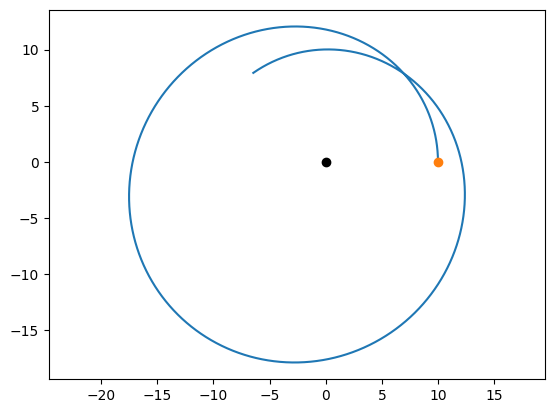

In [7]:
plt.plot(x, y, "-")
plt.plot(0, 0, "ok", label="Black Hole")
plt.plot(x[0], y[0], "o", label="Start")
plt.axis("equal")

In [8]:
from relatipy.numeric.metrics import Kerr
from relatipy.numeric.coordinates import BoyerLindquist, Spherical

In [9]:
kerr = Kerr(mass=1, a=a)

Ic = Spherical(
    xs=[0, r0, th0, 0],
    vels=list(vels),
)

# taus is proper time; EinsteinPy's max(t) above is coordinate time, so the
# two spans do not match one-for-one. 400 covers more than one radial period
# of preset B; raise it to see the periastron precession accumulate.
path = kerr.geodesic.get_path(Ic, taus=(0, 400)).convert_to("Cartesian")

In [10]:
t2, x2, y2, z2, dx2, dy2, dz2 = path.state_vector

In [11]:
x2[0], y2[0], z2[0]

(np.float64(10.0), np.float64(0.0), np.float64(6.123233995736766e-16))

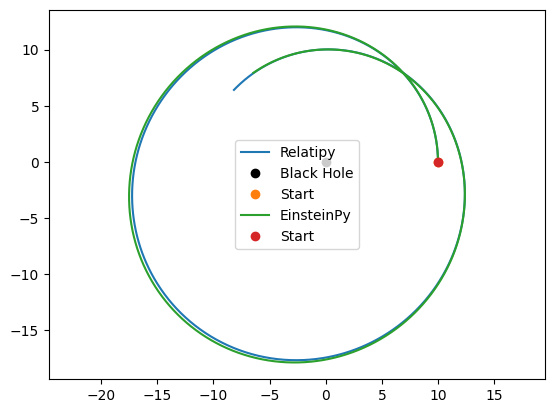

In [12]:
plt.plot(x2, y2, "-", label="Relatipy")
plt.plot(0, 0, "ok", label="Black Hole")
plt.plot(x2[0], y2[0], "o", label="Start")

plt.plot(x, y, "-", label="EinsteinPy")
plt.plot(x[0], y[0], "o", label="Start")
plt.axis("equal")
plt.legend()

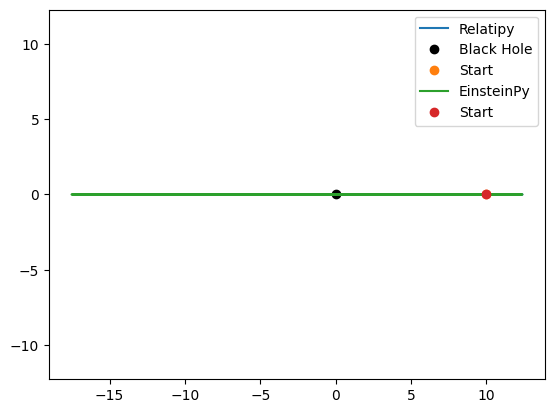

In [13]:
# x-z plane: only meaningful for preset C (p_th != 0)
plt.plot(x2, z2, "-", label="Relatipy")
plt.plot(0, 0, "ok", label="Black Hole")
plt.plot(x2[0], z2[0], "o", label="Start")

plt.plot(x, z, "-", label="EinsteinPy")
plt.plot(x[0], z[0], "o", label="Start")
plt.axis("equal")
plt.legend()